# Machine Learning Modelling

## Introduction

The previous notebooks established that historical AQI, regional biomass burning, and meteorological conditions are all significantly associated with next-day air quality. Based on these findings, this notebook develops machine learning models to predict Delhi's next-day AQI using the engineered features.

The objectives of this notebook are to compare the predictive performance of multiple machine learning algorithms, identify the most accurate model, and evaluate the relative importance of the predictor variables. The results provide practical evidence of how effectively historical pollution, fire activity, and weather conditions can be combined to forecast next-day AQI.

## 2. Import Required Libraries

The libraries required for data manipulation, model development, evaluation, and visualization are imported before the modelling process begins.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 3. Load the Feature Engineered Dataset

The feature-engineered dataset generated in the previous notebook is loaded for machine learning model development. This dataset contains historical AQI, biomass burning, meteorological variables, engineered features, and the target variable required for next-day AQI prediction.

In [3]:
feature_df = pd.read_csv(
    "feature_engineered_dataset.csv"
)

feature_df.head()

,Date,AQI,AQI_Bucket,PM2.5,Fire_Count,Total_FRP,Mean_FRP,Max_FRP,Mean_U10,Mean_V10,...,AQI_lag1,AQI_lag2,AQI_lag3,AQI_rolling_mean_3,AQI_rolling_std_3,Fire_Count_lag1,Fire_Count_lag2,Total_FRP_lag1,Total_FRP_lag2,AQI_next_day
0,2015-01-04,319.0,Very Poor,151.84,15,81.51,5.434000,15.46,1.773298,-1.831503,...,143.0,454.0,472.0,356.333333,184.971169,4.0,15.0,5.93,84.92,325.0
1,2015-01-05,325.0,Very Poor,146.60,34,110.50,3.250000,8.84,4.105233,-2.425379,...,319.0,143.0,454.0,305.333333,155.949778,15.0,4.0,81.51,5.93,318.0
2,2015-01-06,318.0,Very Poor,149.58,27,78.98,2.925185,5.09,1.927311,-1.480514,...,325.0,319.0,143.0,262.333333,103.389232,34.0,15.0,110.50,81.51,353.0
3,2015-01-07,353.0,Very Poor,217.87,5,14.42,2.884000,3.44,0.352872,-1.366974,...,318.0,325.0,319.0,320.666667,3.785939,27.0,34.0,78.98,110.50,383.0
4,2015-01-08,383.0,Very Poor,229.90,10,62.42,6.242000,17.37,0.695696,-1.075948,...,353.0,318.0,325.0,332.000000,18.520259,5.0,27.0,14.42,78.98,375.0


## 4. Feature Selection

The feature-engineered dataset contains historical AQI, biomass burning, meteorological, and temporal variables. Before model development, the predictor variables and target variable are selected. The `Date` column is excluded because it serves only as a temporal identifier and does not provide meaningful numerical information for model training.

In [4]:
X = feature_df.drop(
    columns=[
        "Date",
        "AQI_next_day",
        "AQI_Bucket"
    ]
)

y = feature_df["AQI_next_day"]

In [5]:
print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (1847, 25)
Target Vector Shape  : (1847,)


In [6]:
X.columns

Index(['AQI', 'PM2.5', 'Fire_Count', 'Total_FRP', 'Mean_FRP', 'Max_FRP',
       'Mean_U10', 'Mean_V10', 'Mean_Wind_Speed', 'Max_Wind_Speed',
       'Avg_Temperature_C', 'Avg_DewPoint_C', 'Relative_Humidity', 'Month',
       'Day_of_Week', 'Season', 'AQI_lag1', 'AQI_lag2', 'AQI_lag3',
       'AQI_rolling_mean_3', 'AQI_rolling_std_3', 'Fire_Count_lag1',
       'Fire_Count_lag2', 'Total_FRP_lag1', 'Total_FRP_lag2'],
      dtype='object')

## 5. Train-Test Split

To simulate a realistic forecasting scenario, the dataset is divided chronologically rather than randomly. The earliest 80% of the observations are used for model training, while the remaining 20% are reserved for testing.

This approach ensures that the models are trained only on historical observations and evaluated on future data, preventing information from future time periods from influencing the training process.

In [7]:
# Define the split index (80% training, 20% testing)
split_index = int(len(feature_df) * 0.8)

# Chronological split
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (1477, 25)
Testing Features  : (370, 25)

Training Target   : (1477,)
Testing Target    : (370,)


In [9]:
print("Training Period")
print(feature_df.iloc[:split_index]["Date"].min(), "to",
      feature_df.iloc[:split_index]["Date"].max())

print()

print("Testing Period")
print(feature_df.iloc[split_index:]["Date"].min(), "to",
      feature_df.iloc[split_index:]["Date"].max())

Training Period
2015-01-04 to 2019-05-23

Testing Period
2019-05-24 to 2020-06-30


### Findings

The dataset was successfully divided into chronological training and testing subsets using an 80:20 ratio. The training set contains 1,477 observations from January 2015 to May 2019, while the testing set contains the remaining 370 observations from May 2019 to June 2020. Preserving the temporal order ensures that the models are trained only on historical information and evaluated on unseen future observations, providing a realistic assessment of their forecasting capability.

## 6. Baseline Model Development

Three machine learning models are developed to predict next-day AQI. A Linear Regression model is first trained as a baseline, followed by Random Forest and XGBoost. Comparing these models helps determine whether more advanced algorithms provide improved predictive performance over a simple linear approach.

### 6.1 Linear Regression

Linear Regression is used as the baseline model because it is simple, interpretable, and provides a useful reference for evaluating the performance of more advanced machine learning algorithms.

In [10]:
# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Generate predictions
lr_predictions = lr_model.predict(X_test)

In [11]:
# Evaluation metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

MAE  : 32.30
RMSE : 43.12
R²   : 0.8540


### Findings

The Linear Regression model achieved an MAE of **32.30**, an RMSE of **43.12**, and an R² score of **0.8540** on the testing dataset. These results indicate that the model explains approximately **85.4% of the variation** in next-day AQI despite its simple linear assumptions.

The model provides a strong baseline for comparison with more advanced machine learning algorithms. However, because AQI is influenced by complex and non-linear interactions between historical pollution levels, biomass burning, and meteorological conditions, more sophisticated ensemble models such as Random Forest and XGBoost are expected to further improve predictive performance.

### 6.2 Random Forest Regression

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. Unlike Linear Regression, Random Forest can capture complex non-linear relationships between historical AQI, biomass burning, and meteorological variables, making it well suited for environmental prediction problems.

In [12]:
# Initialize the model
rf_model = RandomForestRegressor(
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Generate predictions
rf_predictions = rf_model.predict(X_test)

In [13]:
# Evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

MAE  : 28.54
RMSE : 39.93
R²   : 0.8748


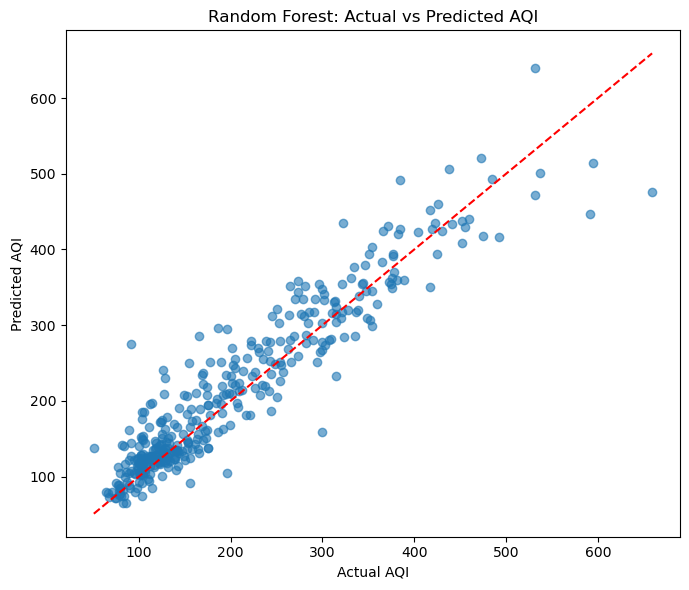

In [14]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Random Forest: Actual vs Predicted AQI")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.tight_layout()
plt.show()

### Findings

The Random Forest model achieved an MAE of **28.54**, an RMSE of **39.93**, and an R² score of **0.8748**, outperforming the baseline Linear Regression model across all evaluation metrics. This indicates that the ensemble model is better able to capture the complex relationships between historical AQI, biomass burning, and meteorological variables.

The Actual versus Predicted scatter plot shows that most predictions closely follow the ideal diagonal line, demonstrating good predictive accuracy across the majority of AQI values. However, the model exhibits a slight tendency to underestimate a small number of extremely high AQI observations, suggesting that severe pollution episodes remain more challenging to predict accurately.

### 6.3 XGBoost Regression

XGBoost is a gradient boosting algorithm that builds decision trees sequentially, with each new tree correcting the errors of the previous ones. It is widely used for tabular prediction problems because it can effectively model complex non-linear relationships while maintaining strong predictive performance.

In [15]:
# Initialize the model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Generate predictions
xgb_predictions = xgb_model.predict(X_test)

In [16]:
# Evaluation metrics
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

MAE  : 30.71
RMSE : 42.36
R²   : 0.8591


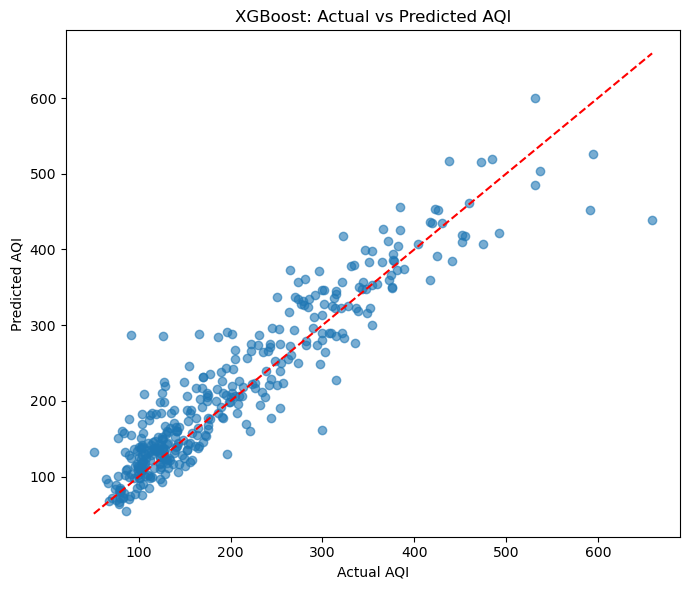

In [17]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    xgb_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("XGBoost: Actual vs Predicted AQI")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.tight_layout()
plt.show()

### Findings

The three baseline models were evaluated using MAE, RMSE, and R² on the chronological test dataset. Among them, **Random Forest achieved the best predictive performance**, with the lowest prediction errors (MAE = 28.54, RMSE = 39.93) and the highest coefficient of determination (R² = 0.8748).

Although XGBoost also captured the underlying relationships in the data, its baseline performance was slightly lower than that of Random Forest. Therefore, Random Forest was selected as the most promising model for further optimisation through hyperparameter tuning.

## 7. Baseline Model Comparison

The baseline performance of Linear Regression, Random Forest, and XGBoost is compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). This comparison identifies the strongest baseline model for subsequent hyperparameter tuning.

In [18]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],
    "R2": [lr_r2, rf_r2, xgb_r2]
})

comparison_df

,Model,MAE,RMSE,R2
0,Linear Regression,32.297033,43.119401,0.854015
1,Random Forest,28.537081,39.934696,0.874783
2,XGBoost,30.710624,42.364347,0.859083


In [19]:
comparison_df = comparison_df.sort_values(by="R2", ascending=False)

comparison_df

,Model,MAE,RMSE,R2
1,Random Forest,28.537081,39.934696,0.874783
2,XGBoost,30.710624,42.364347,0.859083
0,Linear Regression,32.297033,43.119401,0.854015


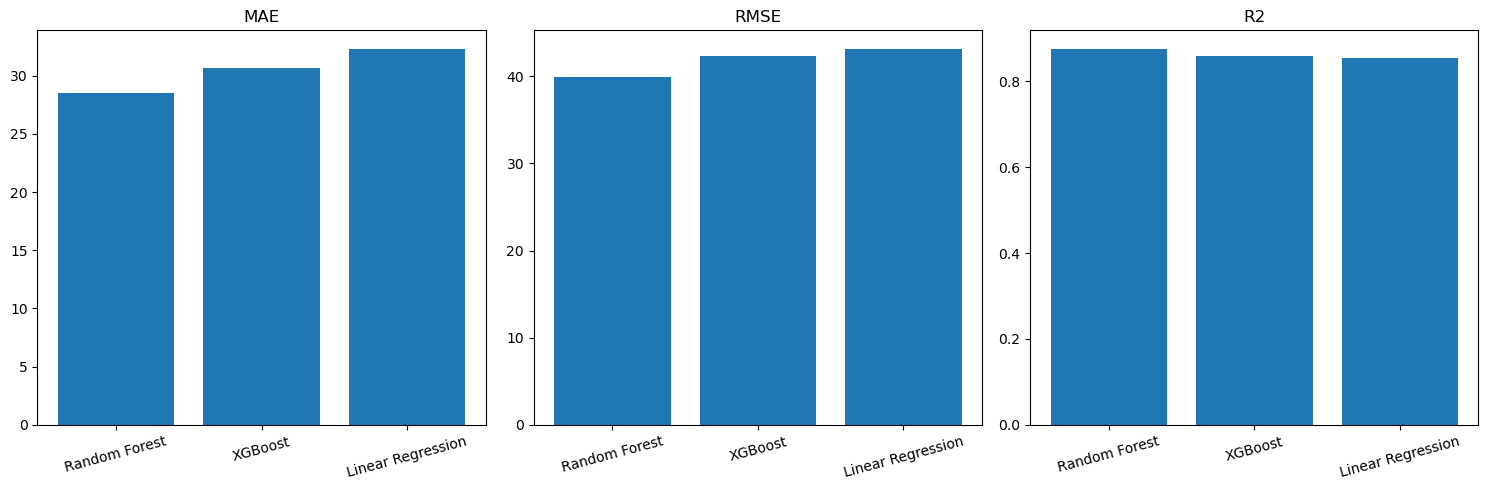

In [20]:
metrics = ["MAE", "RMSE", "R2"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, metrics):
    ax.bar(comparison_df["Model"], comparison_df[metric])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### Findings

The comparison of the baseline models shows that Random Forest achieved the best overall performance, followed by XGBoost and Linear Regression. The lower MAE and RMSE values indicate that Random Forest produced more accurate predictions, while its higher R² score demonstrates a better ability to explain the variability in next-day AQI. Based on these results, Random Forest was selected for hyperparameter tuning to investigate whether its predictive performance can be further improved.

## 8. Hyperparameter Tuning

The baseline comparison identified Random Forest as the best-performing model. To further improve its predictive performance, hyperparameter tuning is performed using GridSearchCV. Since the dataset represents chronological observations, TimeSeriesSplit is used during cross-validation to preserve the temporal order of the data and avoid information leakage from future observations.

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

### 8.1 Time Series Cross-Validation

TimeSeriesSplit is used instead of standard K-Fold cross-validation because the objective is to forecast future AQI using historical observations. This ensures that each validation fold contains observations that occur later in time than the corresponding training fold, providing a realistic evaluation during hyperparameter tuning.

In [22]:
tscv = TimeSeriesSplit(n_splits=5)

In [23]:
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train), start=1):

    print(f"Fold {fold}")

    print("Train :", train_idx[0], "-", train_idx[-1])

    print("Test  :", test_idx[0], "-", test_idx[-1])

    print("-"*40)

Fold 1
Train : 0 - 246
Test  : 247 - 492
----------------------------------------
Fold 2
Train : 0 - 492
Test  : 493 - 738
----------------------------------------
Fold 3
Train : 0 - 738
Test  : 739 - 984
----------------------------------------
Fold 4
Train : 0 - 984
Test  : 985 - 1230
----------------------------------------
Fold 5
Train : 0 - 1230
Test  : 1231 - 1476
----------------------------------------


In [24]:
param_grid = {

    "n_estimators":[100,200],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

### Findings

The TimeSeriesSplit procedure successfully divided the training dataset into five sequential folds. In each fold, the training set expands while the validation set contains observations that occur later in time. This approach preserves the chronological order of the data and provides a realistic evaluation during hyperparameter tuning by ensuring that future observations are never used to train the model.

### 8.2 Grid Search

GridSearchCV systematically evaluates multiple combinations of Random Forest hyperparameters using TimeSeriesSplit cross-validation. The combination that minimizes the Root Mean Squared Error (RMSE) across the validation folds is selected as the optimal model.

In [25]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),

    param_grid=param_grid,

    cv=tscv,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1,

    verbose=1
)

In [26]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [27]:
print("Best Parameters:")
print(grid_search.best_params_)

print()

print("Best RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best RMSE:
58.53662055698278


### Findings

GridSearchCV identified the optimal Random Forest hyperparameters using TimeSeriesSplit cross-validation. The selected model consists of **100 decision trees**, allows unrestricted tree depth, requires at least **5 samples** to split an internal node, and **2 samples** in each terminal leaf. These settings balance model complexity and generalization, reducing the likelihood of overfitting while maintaining strong predictive capability.

The best cross-validation RMSE obtained during hyperparameter tuning was **58.54**. This value represents the average validation performance across multiple chronological folds and serves as the criterion for selecting the optimal model configuration.

### 8.3 Final Tuned Random Forest

The optimal hyperparameters obtained from GridSearchCV are used to train the final Random Forest model. The tuned model is then evaluated on the untouched testing dataset to assess its forecasting performance on unseen observations.

In [28]:
# Train the final tuned model
best_rf = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

# Predictions
best_rf_predictions = best_rf.predict(X_test)

In [29]:
# Evaluation metrics
best_rf_mae = mean_absolute_error(y_test, best_rf_predictions)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_predictions))
best_rf_r2 = r2_score(y_test, best_rf_predictions)

print(f"MAE  : {best_rf_mae:.2f}")
print(f"RMSE : {best_rf_rmse:.2f}")
print(f"R²   : {best_rf_r2:.4f}")

MAE  : 28.34
RMSE : 39.63
R²   : 0.8767


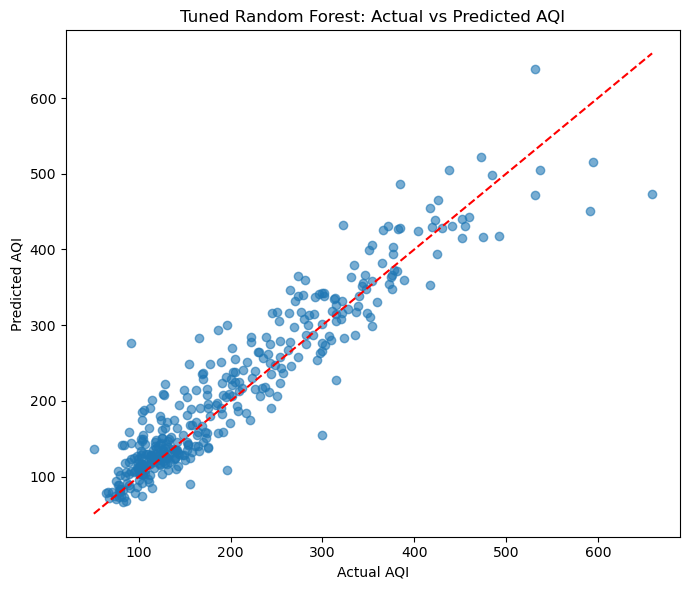

In [30]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, best_rf_predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Tuned Random Forest: Actual vs Predicted AQI")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.tight_layout()
plt.show()

### Findings

The tuned Random Forest model achieved an MAE of **28.34**, an RMSE of **39.63**, and an R² score of **0.8767**, slightly improving upon the baseline Random Forest model. The reduction in prediction error and the increase in the coefficient of determination indicate that hyperparameter tuning enhanced the model's ability to generalize to unseen observations.

Although the performance improvement was modest, the tuned model consistently outperformed the baseline across all evaluation metrics. Therefore, the tuned Random Forest model was selected as the final predictive model for subsequent interpretation and analysis.

## 9. Baseline vs Tuned Random Forest Comparison

The performance of the baseline and tuned Random Forest models is compared to evaluate the effectiveness of hyperparameter tuning. The comparison is based on MAE, RMSE, and R² using the same testing dataset.

In [31]:
rf_comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Baseline Random Forest": [
        rf_mae,
        rf_rmse,
        rf_r2
    ],
    "Tuned Random Forest": [
        best_rf_mae,
        best_rf_rmse,
        best_rf_r2
    ]
})

rf_comparison

,Metric,Baseline Random Forest,Tuned Random Forest
0,MAE,28.537081,28.338364
1,RMSE,39.934696,39.627759
2,R²,0.874783,0.876700


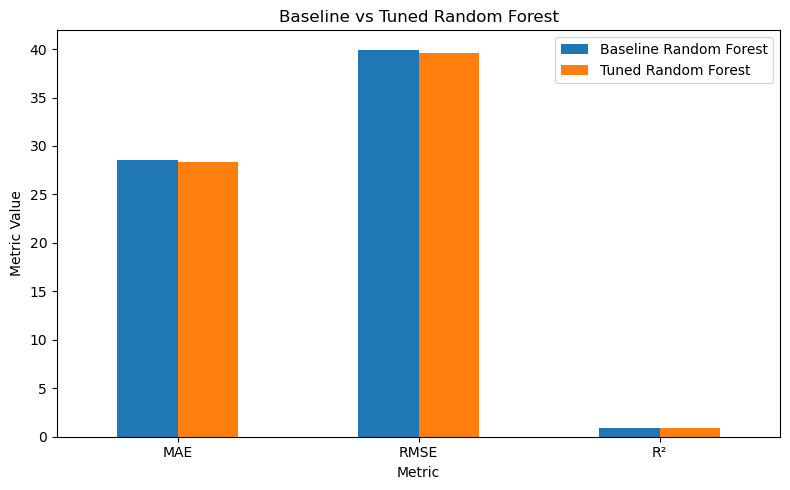

In [32]:
rf_comparison_plot = rf_comparison.set_index("Metric")

rf_comparison_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline vs Tuned Random Forest")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Findings

Hyperparameter tuning produced a modest but consistent improvement in the predictive performance of the Random Forest model. The tuned model achieved lower MAE and RMSE values while also obtaining a slightly higher R² score than the baseline model. These results indicate that the selected hyperparameters improved the model's generalization capability without introducing overfitting.

## 10. Feature Importance

The tuned Random Forest model is used to estimate the relative importance of each predictor variable. Feature importance measures the contribution of each variable toward reducing prediction error across all decision trees in the model.

This analysis helps identify the most influential historical AQI, biomass burning, meteorological, and temporal variables for predicting Delhi's next-day AQI.

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,AQI,0.579312
1,PM2.5,0.269118
9,Max_Wind_Speed,0.012313
6,Mean_U10,0.011333
7,Mean_V10,0.010435
11,Avg_DewPoint_C,0.009462
12,Relative_Humidity,0.008554
20,AQI_rolling_std_3,0.008547
8,Mean_Wind_Speed,0.008447
5,Max_FRP,0.008282


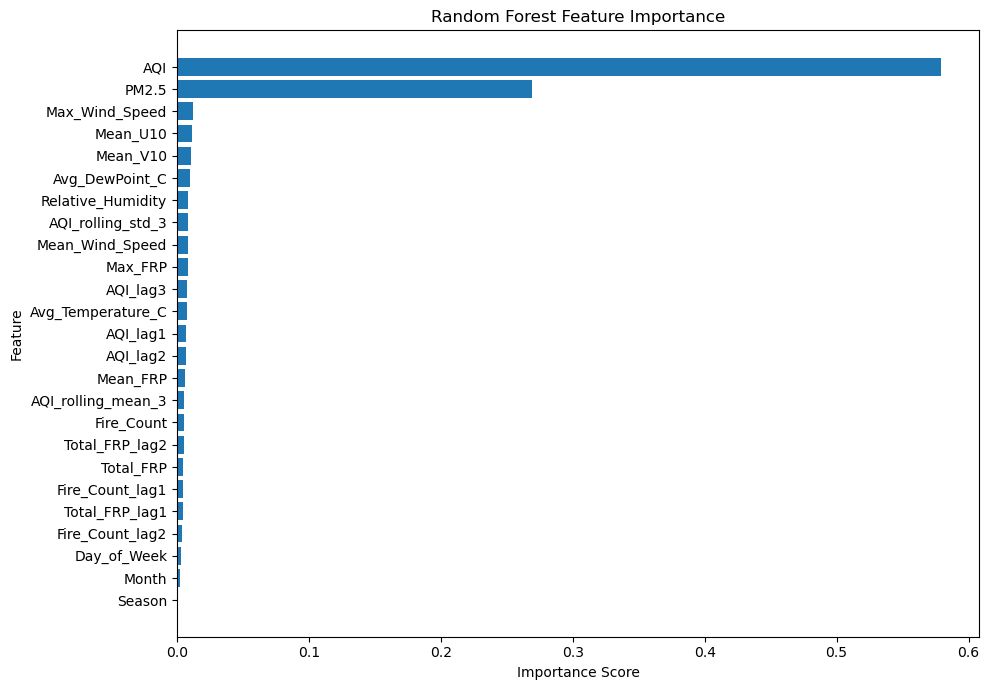

In [34]:
plt.figure(figsize=(10,7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

### Findings

The feature importance analysis indicates that the current day's AQI is the strongest predictor of next-day AQI, followed by PM2.5 concentration. Together, these variables account for the majority of the model's predictive capability, reflecting the strong temporal persistence of air pollution.

Meteorological variables such as wind speed, wind components, dew point, and relative humidity contribute to the prediction but with considerably lower importance. Fire-related variables also contribute, although their importance is comparatively smaller when current pollution indicators are included in the model.

## 11. Prediction Results

The tuned Random Forest model is evaluated by comparing the predicted AQI values with the corresponding observed AQI values from the testing dataset. This comparison provides a practical demonstration of the model's ability to capture the temporal variation in next-day AQI.

In [41]:
prediction_results = pd.DataFrame({

    "Date": feature_df.iloc[split_index:]["Date"].values,

    "Actual AQI": y_test.values,

    "Predicted AQI": np.round(best_rf_predictions,2)

})

prediction_results.head(20)

,Date,Actual AQI,Predicted AQI
0,2019-05-24,125.0,151.29
1,2019-05-25,135.0,152.54
2,2019-05-26,163.0,154.62
3,2019-05-27,175.0,191.02
4,2019-05-28,191.0,223.78
5,2019-05-29,226.0,215.76
6,2019-05-30,266.0,246.22
7,2019-05-31,300.0,265.27
8,2019-06-01,222.0,284.41
9,2019-06-02,232.0,206.81


In [40]:
prediction_results["Date"] = pd.to_datetime(
    prediction_results["Date"]
)

In [43]:
prediction_results["Date"] = pd.to_datetime(prediction_results["Date"])

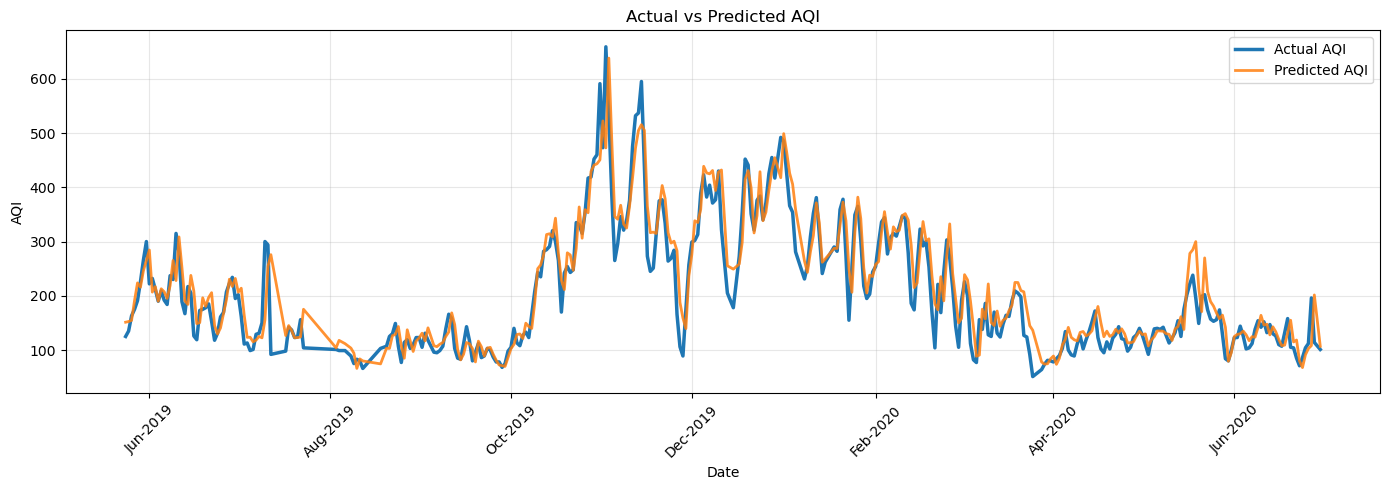

In [45]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14, 5))

dates = pd.to_datetime(prediction_results["Date"])

plt.plot(
    dates,
    prediction_results["Actual AQI"],
    label="Actual AQI",
    linewidth=2.5
)

plt.plot(
    dates,
    prediction_results["Predicted AQI"],
    label="Predicted AQI",
    linewidth=2,
    alpha=0.85
)

plt.title("Actual vs Predicted AQI")
plt.xlabel("Date")
plt.ylabel("AQI")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.xticks(rotation=45)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Findings

The tuned Random Forest model closely follows the observed AQI throughout the testing period, demonstrating its ability to capture the temporal variation in Delhi's air quality. Although minor differences are observed during periods of extremely high AQI, the model successfully identifies the overall trends, seasonal variations, and pollution peaks. The visual comparison supports the evaluation metrics obtained earlier, confirming that the tuned Random Forest model provides accurate and reliable next-day AQI predictions.

## 12. Summary

In this notebook, multiple machine learning models were developed and evaluated for next-day AQI prediction. Linear Regression, Random Forest, and XGBoost models were compared using MAE, RMSE, and R² metrics. The Random Forest model achieved the best overall performance and was further optimized using time-series cross-validation and hyperparameter tuning.

The final tuned Random Forest model achieved an MAE of **28.34**, RMSE of **39.63**, and an R² score of **0.8767**, demonstrating strong predictive capability for next-day AQI forecasting. Feature importance analysis identified the variables that contributed most to the model's predictions, while the comparison of actual and predicted AQI values confirmed that the model effectively captures the temporal behaviour of Delhi's air quality.

The tuned Random Forest model is therefore selected for detailed interpretation in the next notebook using feature importance and SHAP analysis to better understand the influence of environmental variables on AQI prediction.